<a href="https://colab.research.google.com/github/Bima34157/data-science-2026/blob/main/pertemuan_13_zaldi_bima_aditya_220401010271.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-13

- Nama    : Zaldi Bima Aditya
- NIM     : 220401010271
- Kelas   : IF405

## Langkah 1: Generate & Eksplorasi Dataset Non-Linear
Membuat dataset `make_moons`, lalu memvisualisasikannya untuk melihat mengapa data ini tidak bisa dipisahkan garis lurus.

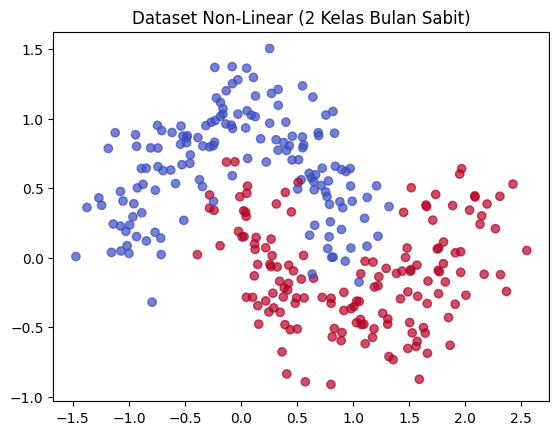

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

## Langkah 2: Bangun & Latih Neural Network Sederhana
Membangun arsitektur neural network dengan activation function ReLU dan Sigmoid, lalu melatih modelnya.

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

## Langkah 3: Evaluasi & Visualisasi Kurva Belajar
Mengevaluasi model pada data uji, lalu memplot kurva akurasi training vs validasi untuk melihat proses belajarnya.

Akurasi pada data uji: 0.900


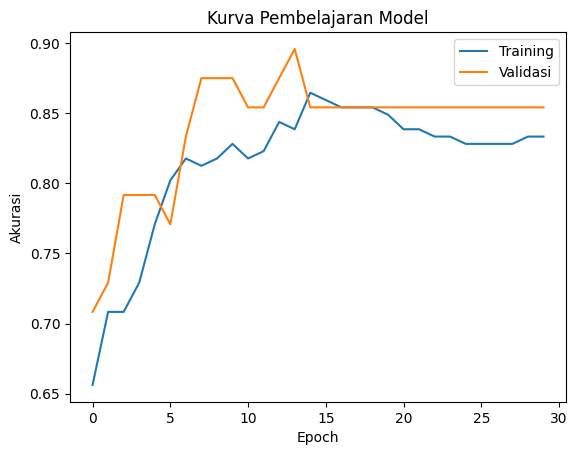

In [5]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?


## Langkah 4: Siapkan Dataset Ulasan Produk
Membuat dataset ulasan produk sederhana (40 ulasan) dengan label sentimen positif/negatif.

In [6]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pelayanan ramah, barang sampai tepat waktu',
    'Produk cacat, penjual tidak responsif',
    'Puas dengan kualitas bahan, awet dipakai',
    'Menyesal beli di sini, kualitas mengecewakan',
    'Pengemasan rapi, barang sesuai foto',
    'Barang tidak original, sangat kecewa',
    'Harga terjangkau, kualitas oke banget',
    'Pengiriman lambat dan barang penyok',
    'Toko terpercaya, akan langganan seterusnya',
    'Ukuran tidak sesuai, mengecewakan sekali',
    'Bahan adem dan nyaman dipakai, suka',
    'Warna belang, tidak sesuai gambar',
    'Pelayanan cepat tanggap, sangat membantu',
    'Barang rusak dan tidak ada garansi',
    'Kualitas premium, worth it banget',
    'Komplain diabaikan, layanan buruk',
    'Sesuai ekspektasi, akan repeat order',
    'Bau tidak sedap, kualitas rendah',
    'Sangat rapi dan cepat, top seller',
    'Produk palsu, sangat mengecewakan',
    'Nyaman dipakai sehari-hari, recommended',
    'Pengiriman salah alamat, tidak profesional',
    'Kualitas jahitan rapi, tidak mudah rusak',
    'Barang cacat produksi, minta refund',
    'Respon cepat, solutif, sangat memuaskan',
    'Ukuran kekecilan, tidak sesuai chart',
    'Bahan premium, harga worth it',
    'Barang beda jauh dari deskripsi',
    'Kemasan aman, tidak ada kerusakan',
    'Kualitas menurun dari pembelian sebelumnya',
    'Sangat direkomendasikan, kualitas juara',
    'Pesanan tidak lengkap, sangat mengecewakan',
    'Fast respon dan ramah, top banget',
    'Barang lecet dan kotor saat diterima',
]

label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

print('Jumlah ulasan:', len(ulasan))
print('Jumlah label:', len(label))
print('Distribusi label:', {1: label.count(1), 0: label.count(0)})


Jumlah ulasan: 40
Jumlah label: 40
Distribusi label: {1: 20, 0: 20}


## Langkah 5: Ubah Teks Menjadi TF-IDF
Mengubah seluruh ulasan menjadi representasi TF-IDF, lalu melihat kata-kata dengan skor tertinggi.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])


Jumlah kata unik: 111
['ada' 'adem' 'akan' 'alamat' 'aman' 'awet' 'bagus' 'bahan' 'banget'
 'barang']


## Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi
Melatih model Logistic Regression sederhana untuk memprediksi sentimen, lalu menguji dengan kalimat baru.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')


Akurasi model sentimen: 0.875


In [9]:
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')


Positif


#Kesimpulan

model Logistic Regression berbasis TF-IDF ini adalah baseline sederhana untuk analisis sentimen — cepat dilatih dan mudah diinterpretasi, tetapi hanya mengandalkan kemunculan kata (tanpa memahami konteks kalimat secara mendalam). Untuk kasus yang lebih kompleks (sarkasme, kalimat panjang, makna kontekstual), pendekatan berbasis Transformer/LLM (mis. BERT) umumnya memberi akurasi yang jauh lebih baik, namun membutuhkan data dan komputasi yang jauh lebih besar dibanding TF-IDF.